# 02 — 第一代：Heuristic Filtering

**方法论定位（第一代）**：人工设计规则，按 FineWeb 实际过滤顺序执行。

| 过滤步骤 | 方法来源 | 检测目标 | 预期过滤率 |
|---------|---------|---------|-----------|
| URL 去重/过滤 | FineWeb | 垃圾域名、黑名单 TLD | 1-5% |
| 语言过滤 | fastText lid.176 | 非英文文档 | 50-75%（CC WET） |
| Gopher 质量 | DeepMind 2021 | 文档级统计异常（长度/字母比/停用词） | 15-30% |
| C4 质量 | Google 2020 | 行级特征（标点/JS/Lorem ipsum） | 10-25% |
| FineWeb 质量 | HuggingFace 2024 | 子弹点堆砌、省略号截断 | 1-5% |
| 重复过滤 | Gopher | 文档内行级/N-gram 重复 | 30-50% |
| PII 脱敏 | Regex | 邮箱/电话/IP 地址 | <1%（脱敏，非过滤） |

> **口径说明**：预期过滤率 = 该步骤丢弃的文档数 / 该步骤的输入文档数（条件过滤率，非全量占比）。来源为各论文在 CC 级别数据上的经验范围。

**本代的核心价值和局限**：
- 可解释、极快、不需要训练
- 能过滤"明显的垃圾"（乱码、广告、模板）
- 无法区分"平庸内容"和"高质量内容"（都能通过规则）
- 规则之间无协同，阈值靠经验

> 本 notebook 读取 pipeline 预计算结果（`data/gen1_output/`），不再逐步运行过滤器。
> Pipeline 脚本：`scripts/run_gen1.py` | 分析脚本：`scripts/gen1_filter_analysis.py`

In [1]:
# === Cell 1: 环境初始化 + 双模式数据加载 ===
import sys
sys.path.insert(0, '..')
import json
import random
import re
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
from src.utils.config_loader import load_run_config, get_output_path, print_config_summary

# --- 双模式数据加载 ---
MODES = ['smoke_test', 'full_run']
MODE_LABELS = {'smoke_test': 'Smoke Test (12K)', 'full_run': 'Full Run (100K)'}
dual_data = {}

# --- 依赖文件校验（双模式） ---
ROOT = Path('..')
REQUIRED_FILES = {
    'CC WET 输入': ROOT / 'data/raw/cc_wet_sample.jsonl',
}
for mode in MODES:
    _cfg = load_run_config(run_mode_override=mode)
    _dir = get_output_path(1, _cfg)
    REQUIRED_FILES[f'Gen1 统计 ({mode})'] = _dir / 'gen1_pipeline_stats.json'
    REQUIRED_FILES[f'Gen1 输出 ({mode})'] = _dir / 'gen1_output.jsonl'

for name, path in REQUIRED_FILES.items():
    assert path.exists(), f"缺少 {name}: {path}\n请先运行: python3 scripts/run_gen1.py"
print(f"依赖文件校验通过（{len(REQUIRED_FILES)} 个文件）")

for mode in MODES:
    mode_cfg = load_run_config(run_mode_override=mode)
    gen1_dir = get_output_path(1, mode_cfg)

    stats_path = gen1_dir / 'gen1_pipeline_stats.json'
    with open(stats_path) as f:
        pipeline_data = json.load(f)

    stage_metrics_path = gen1_dir / 'gen1_stage_metrics.json'
    stage_metrics = []
    if stage_metrics_path.exists():
        with open(stage_metrics_path) as f:
            stage_metrics = json.load(f)

    # 加载详细过滤分析
    analysis_path = gen1_dir / 'gen1_filter_analysis.json'
    filter_analysis = None
    if analysis_path.exists():
        with open(analysis_path) as f:
            filter_analysis = json.load(f)

    dual_data[mode] = {
        'cfg': mode_cfg,
        'gen1_dir': gen1_dir,
        'pipeline_stats': pipeline_data['pipeline_stats'],
        'input_count': pipeline_data['input_count'],
        'output_count': pipeline_data['output_count'],
        'retention_rate': pipeline_data['retention_rate'],
        'stage_metrics': stage_metrics,
        'filter_analysis': filter_analysis,
    }
    print(f"[{mode}] 输入: {pipeline_data['input_count']:,} | "
          f"输出: {pipeline_data['output_count']:,} | "
          f"保留率: {pipeline_data['retention_rate']:.1%}"
          f" | 详细分析: {'有' if filter_analysis else '无'}")

# 默认使用 smoke_test 做详细分析
current_mode = 'smoke_test'
run_cfg = dual_data[current_mode]['cfg']

# 加载原始文档样本和输出文档
raw_docs = []
cc_wet = Path('../data/raw/cc_wet_sample.jsonl')
with open(cc_wet) as f:
    for i, line in enumerate(f):
        if i >= run_cfg['doc_limit']:
            break
        try:
            raw_docs.append(json.loads(line))
        except Exception:
            pass

output_path = dual_data[current_mode]['gen1_dir'] / 'gen1_output.jsonl'
gen1_docs = []
with open(output_path) as f:
    for line in f:
        try:
            gen1_docs.append(json.loads(line))
        except Exception:
            pass

print(f"\n原始文档: {len(raw_docs):,} 条 | Gen1 输出: {len(gen1_docs):,} 条")

依赖文件校验通过（5 个文件）
[smoke_test] 输入: 12,000 | 输出: 409 | 保留率: 3.4% | 详细分析: 有
[full_run] 输入: 100,000 | 输出: 3,242 | 保留率: 3.2% | 详细分析: 有



原始文档: 12,000 条 | Gen1 输出: 409 条


## A. 逐阶段过滤总览

双模式对比表，每个过滤器显示：输入 → 输出（分子/分母 = 过滤率），对比工业界预期值。

In [2]:
# === Cell 2: 双模式逐阶段对比表（含预期值） ===
step_names = {
    'url_dedup': 'URL 去重',
    'url_filter': 'URL 过滤',
    'language_filter': '语言过滤',
    'quality_filter': '质量过滤(Gopher+C4+FineWeb)',
    'repetition_filter': '重复过滤',
    'pii_filter': 'PII 脱敏',
}

# 工业界预期过滤率（分子=过滤数, 分母=该步输入数）
# 来源: FineWeb/DCLM/RedPajama 论文 + CC WET 数据特性
EXPECTED_RATES = {
    'url_dedup': ('0.1-1%', '精确 URL 去重，CC WET segment 内重复率低'),
    'url_filter': ('1-5%', '黑名单域名 + 关键词，FineWeb 约 2-3%'),
    'language_filter': ('50-75%', 'CC WET 随机 segment 英文仅约 25-35%'),
    'quality_filter': ('40-70%', 'Gopher+C4+FineWeb 联合，原始 CC 数据中低质量占比高'),
    'repetition_filter': ('30-50%', 'Web 页面模板/导航重复普遍，CC WET 尤其严重'),
    'pii_filter': ('<1%', '脱敏模式下几乎不过滤，只替换 PII 文本'),
}

mode_step_map = {}
for mode in MODES:
    mode_step_map[mode] = {s['step']: s for s in dual_data[mode]['pipeline_stats']}

all_steps = [s['step'] for s in dual_data['smoke_test']['pipeline_stats']]

print("=" * 120)
print(f"  第一代 Heuristic Filtering — 双模式逐阶段对比（含预期值）")
print("=" * 120)
header = f"{'过滤器':<28} {'Smoke Test (12K)':^28} {'Full Run (100K)':^28} {'预期过滤率':^12} {'差异判断':^8}"
print(header)
sub_header = f"{'':<28} {'输入→输出 (过滤数/输入=率)':^28} {'输入→输出 (过滤数/输入=率)':^28}"
print(sub_header)
print("-" * 120)

for step in all_steps:
    name = step_names.get(step, step)
    expected = EXPECTED_RATES.get(step, ('N/A', ''))
    parts = []
    rates = []
    for mode in MODES:
        s = mode_step_map[mode].get(step)
        if s:
            parts.append(f"{s['before']:>6,}->{s['after']:<6,} ({s['filtered']}/{s['before']}={s['filter_rate']:.1%})")
            rates.append(s['filter_rate'])
        else:
            parts.append(f"{'N/A':^28}")
            rates.append(0)

    # 判断是否在预期范围内
    avg_rate = np.mean(rates) * 100
    judgment = ''
    if expected[0] != 'N/A':
        try:
            lo, hi = expected[0].replace('%', '').replace('<', '0-').split('-')
            lo, hi = float(lo), float(hi)
            if avg_rate < lo:
                judgment = '偏低'
            elif avg_rate > hi:
                judgment = '偏高'
            else:
                judgment = '正常'
        except Exception:
            judgment = '-'

    print(f"  {name:<26} {parts[0]:^28} {parts[1]:^28} {expected[0]:^12} {judgment:^8}")

print("-" * 120)
# 总计行
parts = []
for mode in MODES:
    d = dual_data[mode]
    total_f = d['input_count'] - d['output_count']
    total_r = 1 - d['retention_rate']
    parts.append(f"{d['input_count']:>6,}->{d['output_count']:<6,} ({total_f}/{d['input_count']}={total_r:.1%})")
print(f"  {'总计':<26} {parts[0]:^28} {parts[1]:^28}")
print("=" * 120)

# 一致性分析
smoke_rate = dual_data['smoke_test']['retention_rate']
full_rate = dual_data['full_run']['retention_rate']
diff_pct = abs(smoke_rate - full_rate) / full_rate * 100 if full_rate > 0 else 0
print(f"\n两档保留率: Smoke={smoke_rate:.2%}, Full={full_rate:.2%}, 差异={diff_pct:.1f}% "
      f"({'一致性良好' if diff_pct < 20 else '存在显著差异'})")

  第一代 Heuristic Filtering — 双模式逐阶段对比（含预期值）
过滤器                                Smoke Test (12K)             Full Run (100K)           预期过滤率       差异判断  
                                   输入→输出 (过滤数/输入=率)             输入→输出 (过滤数/输入=率)      
------------------------------------------------------------------------------------------------------------------------
  URL 去重                     12,000->11,997 (3/12000=0.0%) 100,000->99,896 (104/100000=0.1%)    0.1-1%       偏低   
  URL 过滤                     11,997->11,851 (146/11997=1.2%) 99,896->98,452 (1444/99896=1.4%)     1-5%        正常   
  语言过滤                       11,851->2,912  (8939/11851=75.4%) 98,452->24,026 (74426/98452=75.6%)    50-75%       偏高   
  质量过滤(Gopher+C4+FineWeb)     2,912->832    (2080/2912=71.4%) 24,026->6,539  (17487/24026=72.8%)    40-70%       偏高   
  重复过滤                          832->409    (423/832=50.8%)  6,539->3,242  (3297/6539=50.4%)    30-50%       偏高   
  PII 脱敏                        409->409    (0/409=0.0%

## B. URL 过滤 — 子类别分解

**过滤规则**：
1. 域名黑名单（已知垃圾/成人站点）
2. TLD 黑名单（.tk/.ml/.ga/.cf/.gq — 高垃圾率）
3. URL 关键词（porn/casino/viagra 等）
4. IP 地址直接访问（爬虫蜜罐风险）
5. 空/无效 URL

In [3]:
# === Cell 3: URL 过滤子类别分解 ===
fa = dual_data['smoke_test'].get('filter_analysis')
if not fa:
    print("详细分析数据不可用，请先运行: python scripts/gen1_filter_analysis.py")
else:
    uf = fa['url_filter']
    print(f"URL 过滤: {uf['input']:,} 输入 -> {uf['output']:,} 输出")
    print(f"  过滤数/输入 = {uf['filtered']}/{uf['input']} = {uf['filtered']/uf['input']:.2%}")
    print(f"  预期: 1-5% | 实际: {uf['filtered']/uf['input']:.2%}\n")

    print("子类别分解（分子=该类过滤数, 分母=URL过滤总数）:")
    print(f"  {'子类别':<25} {'过滤数':>8} {'占比':>8}")
    print(f"  {'-'*45}")
    for reason, count in sorted(uf['reason_breakdown'].items(), key=lambda x: -x[1]):
        print(f"  {reason:<25} {count:>8,} {count/uf['filtered']:>8.1%}")

    # 详细关键词分解（取 Top 10）
    print(f"\nTop 10 具体触发原因:")
    detail = uf.get('detail_breakdown', {})
    for i, (reason, count) in enumerate(sorted(detail.items(), key=lambda x: -x[1])[:10]):
        print(f"  {i+1:>2}. {reason:<35} {count:>5,}")

    # 被过滤样例
    examples = fa['per_filter_examples'].get('url_filter', [])
    if examples:
        print(f"\n被过滤文档样例（{len(examples)} 条）:")
        for i, ex in enumerate(examples, 1):
            print(f"  [{i}] URL: {ex['url'][:80]}")
            print(f"      原因: {ex['reason']}")
            text = re.sub(r'[\ud800-\udfff]', '', ex['text_preview'][:100])
            print(f"      文本: {text}...")

URL 过滤: 12,000 输入 -> 11,854 输出
  过滤数/输入 = 146/12000 = 1.22%
  预期: 1-5% | 实际: 1.22%

子类别分解（分子=该类过滤数, 分母=URL过滤总数）:
  子类别                            过滤数       占比
  ---------------------------------------------
  blacklist_keyword              135    92.5%
  ip_address_url                   7     4.8%
  blacklist_tld                    4     2.7%

Top 10 具体触发原因:
   1. blacklist_keyword:casino               30
   2. blacklist_keyword:sex                  24
   3. blacklist_keyword:porn                 22
   4. blacklist_keyword:adult                13
   5. blacklist_keyword:cialis               10
   6. blacklist_keyword:xxx                   9
   7. blacklist_keyword:poker                 8
   8. ip_address_url                          7
   9. blacklist_keyword:slots                 4
  10. blacklist_keyword:nude                  4

被过滤文档样例（5 条）:
  [1] URL: http://giaiphapdoanhnghiepviettel.vn/viettel-advanced-malware-analysis-vcs-ama
      原因: blacklist_keyword:malware
      文本: #1 Bảng 

## C. 语言过滤 — 语言分布详情

**原理**：fastText lid.176 模型检测文档语言，仅保留英文（置信度 >= 0.65）。

**CC WET 数据特性**：随机 segment 中英文仅约 25-35%，远低于 FineWeb 预处理数据的 90%+。
语言过滤是本 pipeline 中过滤量最大的步骤。

In [4]:
# === Cell 4: 语言过滤详情 ===
fa = dual_data['smoke_test'].get('filter_analysis')
if not fa:
    print("详细分析数据不可用")
else:
    lf = fa['language_filter']
    total_lang = sum(lf['language_distribution'].values())
    en_count = lf['english_count']
    en_ratio = lf['english_ratio']

    print(f"语言过滤: {lf['input']:,} 输入 -> {lf['output']:,} 输出")
    print(f"  过滤数/输入 = {lf['filtered']}/{lf['input']} = {lf['filtered']/lf['input']:.2%}")
    print(f"  预期: 50-75% | 实际: {lf['filtered']/lf['input']:.2%}\n")

    print(f"语言分布（检测到的所有文档）:")
    print(f"  英文文档: {en_count:,} / {total_lang:,} = {en_ratio:.1%}")
    print(f"  {'语言':<8} {'文档数':>8} {'占比':>8} {'累计':>8}")
    print(f"  {'-'*36}")
    cumsum = 0
    for lang, count in sorted(lf['language_distribution'].items(), key=lambda x: -x[1])[:15]:
        cumsum += count / total_lang
        print(f"  {lang:<8} {count:>8,} {count/total_lang:>8.1%} {cumsum:>8.1%}")

    # 被过滤样例（不同语言各一条）
    examples = fa['per_filter_examples'].get('language_filter', [])
    if examples:
        print(f"\n被过滤样例（不同语言各 1 条，共 {len(examples)} 条）:")
        for i, ex in enumerate(examples, 1):
            print(f"  [{i}] 语言: {ex.get('detected_lang', 'N/A')}")
            print(f"      URL: {ex['url'][:80]}")
            text = re.sub(r'[\ud800-\udfff]', '', ex['text_preview'][:100])
            print(f"      文本: {text}...")

语言过滤: 20,796 输入 -> 2,912 输出
  过滤数/输入 = 8942/20796 = 43.00%
  预期: 50-75% | 实际: 43.00%

语言分布（检测到的所有文档）:
  英文文档: 4,099 / 11,293 = 34.6%
  语言            文档数       占比       累计
  ------------------------------------
  en          4,099    36.3%    36.3%
  zh          1,488    13.2%    49.5%
  ja          1,212    10.7%    60.2%
  ru          1,160    10.3%    70.5%
  fr            590     5.2%    75.7%
  es            482     4.3%    80.0%
  de            466     4.1%    84.1%
  pl            285     2.5%    86.6%
  ko            227     2.0%    88.6%
  pt            208     1.8%    90.5%
  it            192     1.7%    92.2%
  vi            139     1.2%    93.4%
  fa            120     1.1%    94.5%
  tr            105     0.9%    95.4%
  id             99     0.9%    96.3%

被过滤样例（不同语言各 1 条，共 5 条）:
  [1] 语言: ja
      URL: http://interwall.jp/
      文本: INTERW@// – 佐々木充彦のサイト 本文にジャンプ ABOUT CONTACT INTERW@// ABOUT CONTACT Twitter note © sasaki mitsuhiko ...
  [2] 语言: de
      URL: http://blog.

## D. 质量过滤 — Gopher / C4 / FineWeb 三套规则分解

三套规则按顺序串联执行，文档被第一个不通过的规则拦截。

| 规则集 | 来源 | 检测维度 | 核心规则 |
|-------|------|---------|---------|
| Gopher | DeepMind 2021 | 文档级统计 | 词数(50-100K)、字母比(>0.5)、停用词(>=2)、非字母词比(<0.2) |
| C4 | Google 2020 | 行级特征 | 最少行数(3)、句末标点比(>0.1)、JS 内容、Lorem ipsum |
| FineWeb | HuggingFace 2024 | 精炼补充 | 子弹点比例(<0.9)、省略号行比(<0.3)、含字母词比(>0.6) |

In [5]:
# === Cell 5: 质量过滤三套规则子分解 ===
fa = dual_data['smoke_test'].get('filter_analysis')
if not fa:
    print("详细分析数据不可用")
else:
    qf = fa['quality_filter']
    total_qf = qf['filtered']

    print(f"质量过滤总览: {qf['input']:,} 输入 -> {qf['output']:,} 输出")
    print(f"  总过滤数/输入 = {total_qf}/{qf['input']} = {total_qf/qf['input']:.2%}")
    print(f"  预期: 40-70% | 实际: {total_qf/qf['input']:.2%}\n")

    # 三套规则各自贡献
    print("=" * 80)
    print(f"  {'子规则集':<20} {'过滤数':>8} {'占质量过滤总量':>16} {'占该步输入':>12}")
    print("-" * 80)
    for sub_name, label, expected in [
        ('gopher', 'Gopher (文档级)', '15-30%'),
        ('c4', 'C4 (行级)', '10-25%'),
        ('fineweb', 'FineWeb (精炼)', '1-5%'),
    ]:
        sub = qf['sub_filters'][sub_name]
        filtered = sub['filtered']
        pct_of_total = filtered / total_qf if total_qf > 0 else 0
        pct_of_input = filtered / qf['input'] if qf['input'] > 0 else 0
        print(f"  {label:<20} {filtered:>8,} {pct_of_total:>15.1%} {pct_of_input:>11.1%}")
    print("=" * 80)

    # Gopher 子规则分解
    print(f"\n--- Gopher 规则分解（分子=该规则过滤数, 分母=Gopher 总过滤数）---")
    gopher_sub = qf['sub_filters']['gopher']
    for reason, count in sorted(gopher_sub['reason_breakdown'].items(), key=lambda x: -x[1]):
        print(f"  {reason:<30} {count:>6,} / {gopher_sub['filtered']:,} = {count/gopher_sub['filtered']:.1%}")

    # C4 子规则分解
    print(f"\n--- C4 规则分解（分子=该规则过滤数, 分母=C4 总过滤数）---")
    c4_sub = qf['sub_filters']['c4']
    for reason, count in sorted(c4_sub['reason_breakdown'].items(), key=lambda x: -x[1]):
        print(f"  {reason:<30} {count:>6,} / {c4_sub['filtered']:,} = {count/c4_sub['filtered']:.1%}")

    # FineWeb 子规则分解
    fw_sub = qf['sub_filters']['fineweb']
    if fw_sub['filtered'] > 0:
        print(f"\n--- FineWeb 规则分解 ---")
        for reason, count in sorted(fw_sub['reason_breakdown'].items(), key=lambda x: -x[1]):
            print(f"  {reason:<30} {count:>6,}")
    else:
        print(f"\nFineWeb 过滤: 0 条（Gopher+C4 已拦截大部分，FineWeb 为补充规则）")

质量过滤总览: 4,992 输入 -> 832 输出
  总过滤数/输入 = 2080/4992 = 41.67%
  预期: 40-70% | 实际: 41.67%

  子规则集                      过滤数          占质量过滤总量        占该步输入
--------------------------------------------------------------------------------
  Gopher (文档级)              870           41.8%       17.4%
  C4 (行级)                 1,210           58.2%       24.2%
  FineWeb (精炼)                0            0.0%        0.0%

--- Gopher 规则分解（分子=该规则过滤数, 分母=Gopher 总过滤数）---
  too_short                         522 / 870 = 60.0%
  too_many_non_alpha_words          324 / 870 = 37.2%
  low_alpha_ratio                    16 / 870 = 1.8%
  too_many_ellipsis_lines             4 / 870 = 0.5%
  too_few_stop_words                  2 / 870 = 0.2%
  avg_sentence_too_short              1 / 870 = 0.1%
  avg_sentence_too_long               1 / 870 = 0.1%

--- C4 规则分解（分子=该规则过滤数, 分母=C4 总过滤数）---
  low_terminal_punct_ratio          812 / 1,210 = 67.1%
  too_many_short_lines              279 / 1,210 = 23.1%
  contains_javascript

In [6]:
# === Cell 6: 质量过滤被过滤样例（每种子规则 3-5 条） ===
fa = dual_data['smoke_test'].get('filter_analysis')
if not fa:
    print("详细分析数据不可用")
else:
    for sub_name, label in [
        ('gopher_quality', 'Gopher 质量过滤'),
        ('c4_quality', 'C4 质量过滤'),
        ('fineweb_quality', 'FineWeb 质量过滤'),
    ]:
        examples = fa['per_filter_examples'].get(sub_name, [])
        if examples:
            print(f"\n{'='*70}")
            print(f"  {label} — 被过滤样例（{len(examples)} 条，每种子规则各 1 条）")
            print(f"{'='*70}")
            for i, ex in enumerate(examples, 1):
                print(f"  [{i}] 触发规则: {ex['reason']}")
                print(f"      URL: {ex['url'][:80]}")
                text = ex['text_preview'][:150]
                # 清理 surrogate 字符
                text = re.sub(r'[\ud800-\udfff]', '', text)
                print(f"      文本: {text}...")
                print()
        else:
            print(f"\n{label}: 无被过滤样例（该规则集未触发）")


  Gopher 质量过滤 — 被过滤样例（5 条，每种子规则各 1 条）
  [1] 触发规则: too_many_non_alpha_words:0.24
      URL: http://afilreis.blogspot.com/2007/12/ike-ad-1956.html
      文本: Al Filreis: Ike ad 1956 skip to main | skip to sidebar Al Filreis RSS feed Thursday, December 20, 2007 Ike ad 1956 If TV ads for presidential campaign...

  [2] 触发规则: too_short:11<50
      URL: http://blog.jumalileadership.org/category/bahis/
      文本: One moment, please... Please wait while your request is being verified......

  [3] 触发规则: low_alpha_ratio:0.27<0.5
      URL: http://byyourhands.blogspot.com/2015/06/peanut-butter-bacon-and-dark-chocolate.h
      文本: By Your Hands: Peanut Butter, Bacon and Dark Chocolate Cookies skip to main | skip to sidebar Home Featured Artist Tutorials Organize It Trash to Trea...

  [4] 触发规则: too_few_stop_words:0<2
      URL: http://774.saloon.jp/jinny/jinny.cgi?type=edit&page=1&date=04_07_09&ntres=0&word
      文本: よいこノート +Home +Reload +Menu +Catalog +Search ResSort/ Thread/ Notime/ Write/ Edit/ 

## E. 重复过滤 — 行级 + N-gram 级分解

**Gopher 重复过滤器**（单文档内部检测，非跨文档去重）：

| 检测类型 | 规则 | 阈值 | 检测目标 |
|---------|------|------|---------|
| 行级重复 | duplicate_line_fraction | >0.30 | 导航栏/页脚模板复用 |
| 段落重复 | duplicate_paragraph_fraction | >0.30 | 段落级重复 |
| Top N-gram | top_{2,3,4}gram_fraction | >0.20/0.18/0.16 | 关键词堆砌 |
| 重复 N-gram | dup_{5..10}gram_fraction | >0.15..0.10 | 句式重复 |

**注意**：这里是**文档内部**重复检测。跨文档的去重（MinHash/SimHash）在 Notebook 05 分析。

In [7]:
# === Cell 7: 重复过滤子类别分解 ===
fa = dual_data['smoke_test'].get('filter_analysis')
if not fa:
    print("详细分析数据不可用")
else:
    rf = fa['repetition_filter']
    print(f"重复过滤: {rf['input']:,} 输入 -> {rf['output']:,} 输出")
    print(f"  过滤数/输入 = {rf['filtered']}/{rf['input']} = {rf['filtered']/rf['input']:.2%}")
    print(f"  预期: 30-50% | 实际: {rf['filtered']/rf['input']:.2%}\n")

    # 子规则分解
    print("子规则分解（分子=该规则过滤数, 分母=重复过滤总数）:")
    print(f"  {'规则类型':<25} {'过滤数':>8} {'占比':>8} {'检测目标':<20}")
    print(f"  {'-'*65}")

    RULE_DESC = {
        'dup_line_fraction': '行级重复（导航/页脚）',
        'dup_para_fraction': '段落级重复',
        'top_2gram_fraction': 'Top 2-gram 堆砌',
        'top_3gram_fraction': 'Top 3-gram 堆砌',
        'top_4gram_fraction': 'Top 4-gram 堆砌',
        'dup_5gram_fraction': '5-gram 句式重复',
        'dup_6gram_fraction': '6-gram 句式重复',
        'dup_7gram_fraction': '7-gram 句式重复',
        'dup_8gram_fraction': '8-gram 句式重复',
        'dup_9gram_fraction': '9-gram 句式重复',
        'dup_10gram_fraction': '10-gram 句式重复',
    }

    for reason, count in sorted(rf['reason_breakdown'].items(), key=lambda x: -x[1]):
        desc = RULE_DESC.get(reason, reason)
        pct = count / rf['filtered'] if rf['filtered'] > 0 else 0
        print(f"  {reason:<25} {count:>8,} {pct:>8.1%} {desc:<20}")

    # 样例
    examples = fa['per_filter_examples'].get('repetition_filter', [])
    if examples:
        print(f"\n被过滤样例（不同规则各 1 条，共 {len(examples)} 条）:")
        for i, ex in enumerate(examples, 1):
            print(f"  [{i}] 触发规则: {ex['reason']}")
            print(f"      URL: {ex['url'][:80]}")
            text = re.sub(r'[\ud800-\udfff]', '', ex['text_preview'][:120])
            print(f"      文本: {text}...")

重复过滤: 1,255 输入 -> 409 输出
  过滤数/输入 = 423/1255 = 33.71%
  预期: 30-50% | 实际: 33.71%

子规则分解（分子=该规则过滤数, 分母=重复过滤总数）:
  规则类型                           过滤数       占比 检测目标                
  -----------------------------------------------------------------
  dup_5gram_fraction             360    85.1% 5-gram 句式重复         
  dup_line_fraction               51    12.1% 行级重复（导航/页脚）         
  dup_6gram_fraction               4     0.9% 6-gram 句式重复         
  top_3gram_fraction               3     0.7% Top 3-gram 堆砌       
  dup_7gram_fraction               2     0.5% 7-gram 句式重复         
  top_4gram_fraction               2     0.5% Top 4-gram 堆砌       
  dup_8gram_fraction               1     0.2% 8-gram 句式重复         

被过滤样例（不同规则各 1 条，共 5 条）:
  [1] 触发规则: dup_5gram_fraction:0.174>0.15
      URL: http://ejpch.org/ejpch/article/view/1649
      文本: “Waves and waves of excruciating pain”: An interpretative phenomenological analysis of women living with endometriosis |...
  [2] 触发规则: dup_line_fraction:0.5

## F. 五维数据质量演进（Gen1 输入 vs 输出）

对 Gen1 过滤前后的数据分别计算五维质量 profile，量化过滤效果：

| 维度 | 方法 | 过滤后预期变化 |
|------|------|--------------|
| 规模 | 文档数 / 词数 | 显著减少（保留率 ~3%） |
| 质量 | KenLM Wikipedia PPL | 中位数降低（质量提升） |
| 语言 | fastText lid | 英文比例接近 100% |
| 多样性 | N-gram unique ratio + 域名 entropy | 应保持或小幅下降 |
| 毒性 | detoxify | 应降低或持平 |

In [8]:
# === Cell 8: 五维质量 Profile（Gen1 输入 vs 输出） ===
# 使用独立评估器 baseline_profiler，非 pipeline 模块
from src.evaluation.baseline_profiler import compute_profile, print_profile_summary

# 采样计算（KenLM + detoxify 较慢）
sample_size = min(500, len(raw_docs), len(gen1_docs))

print("正在计算 Gen1 输入数据的五维 Profile...")
input_texts = [d.get('text', '') for d in raw_docs]
input_urls = [d.get('url', '') for d in raw_docs]
input_profile = compute_profile(
    input_texts, urls=input_urls,
    sample_size=sample_size,
    model_dir='../data/models',
)

print("\n正在计算 Gen1 输出数据的五维 Profile...")
output_texts = [d.get('text', '') for d in gen1_docs]
output_urls = [d.get('url', '') for d in gen1_docs]
output_profile = compute_profile(
    output_texts, urls=output_urls,
    sample_size=min(sample_size, len(gen1_docs)),
    model_dir='../data/models',
)

print_profile_summary(input_profile, label="Gen1 输入 (原始 CC WET)")
print_profile_summary(output_profile, label="Gen1 输出 (过滤后)")

正在计算 Gen1 输入数据的五维 Profile...


  加载 KenLM 模型: en.arpa.bin


  加载 SentencePiece: en.sp.model


  KenLM PPL 打分:   0%|          | 0/409 [00:00<?, ?doc/s]

  KenLM PPL 打分:  30%|██▉       | 122/409 [00:00<00:00, 1219.04doc/s]

...

  ☣️  毒性打分:  85%|████████▍ | 11/13 [00:31<00:06,  3.01s/batch]

  ☣️  毒性打分:  92%|█████████▏| 12/13 [00:34<00:02,  2.92s/batch]

  ☣️  毒性打分: 100%|██████████| 13/13 [00:36<00:00,  2.62s/batch]

  ☣️  毒性打分: 100%|██████████| 13/13 [00:36<00:00,  2.81s/batch]


  Gen1 输入 (原始 CC WET)

  [规模]
    文档数: 12,000
    总词数: 8,598,933
    平均词数/文档: 717
    中位数词数: 313

  [质量] KenLM Wikipedia Perplexity（采样 409 条）
    中位数: 2150  |  均值: 12013
    P10: 324  |  P25: 1016  |  P75: 5196  |  P90: 43587
      head:    38 (9.3%) — PPL < 300 (高质量，类 Wikipedia)
    middle:    63 (15.4%) — 300 <= PPL < 1000 (中等质量)
      tail:   308 (75.3%) — PPL >= 1000 (低质量)

  [语言] fastText lid（采样 409 条）
    英文占比: 32.5% (133 / 409)
    检测语言数: 31
    平均置信度: 0.870
    Top 5: en:32.5% | zh:14.7% | ja:10.3% | ru:10.3% | fr:5.1%

  [多样性]
    unigram unique ratio: 0.3203
    bigram unique ratio: 0.7141
    trigram unique ratio: 0.8276
    域名 Shannon Entropy: 5.6005 (归一化: 0.9923)

  [毒性] detoxify（采样 409 条）
    toxicity 均值: 0.0400  |  >0.5 占比: 1.96%  |  >0.8 占比: 1.22%
    severe_toxicity: 均值 0.0012, >0.5 = 0.00%
    insult: 均值 0.0071, >0.5 = 0.49%
    identity_attack: 均值 0.0035, >0.5 = 0.24%

  Gen1 输出 (过滤后)

  [规模]
    文档数: 409
    总词数: 354,130
    平均词数/文档: 866
    中位数词数: 508

  [质量] KenL

In [9]:
# === Cell 9: 五维演进对比表 ===
# 将输入和输出的 5 维指标并排对比

def safe_get(profile, *keys, default='N/A'):
    obj = profile
    for k in keys:
        if isinstance(obj, dict):
            obj = obj.get(k, default)
        else:
            return default
    return obj

print("=" * 80)
print("  五维质量演进对比: Gen1 输入 vs 输出")
print("=" * 80)
print(f"  {'指标':<35} {'输入(原始)':>18} {'输出(过滤后)':>18} {'变化':>10}")
print(f"  {'-'*80}")

# 规模
n_in = safe_get(input_profile, 'scale', 'n_docs', default=0)
n_out = safe_get(output_profile, 'scale', 'n_docs', default=0)
print(f"  {'文档数':<35} {n_in:>18,} {n_out:>18,} {n_out/n_in:.1%}" if n_in else "")

w_in = safe_get(input_profile, 'scale', 'avg_words', default=0)
w_out = safe_get(output_profile, 'scale', 'avg_words', default=0)
if isinstance(w_in, (int, float)) and isinstance(w_out, (int, float)):
    print(f"  {'平均词数/文档':<35} {w_in:>18,.0f} {w_out:>18,.0f} {'+' if w_out>w_in else ''}{w_out-w_in:,.0f}")

# 质量
q_in = safe_get(input_profile, 'quality', 'stats', 'median', default=None)
q_out = safe_get(output_profile, 'quality', 'stats', 'median', default=None)
if q_in and q_out and isinstance(q_in, (int, float)):
    direction = 'better' if q_out < q_in else 'worse'
    print(f"  {'KenLM PPL 中位数 (越低越好)':<35} {q_in:>18,.0f} {q_out:>18,.0f} {direction}")

    # Head/Middle/Tail 分桶
    for bucket_name, label in [('head', 'PPL head(<300) 占比'), ('middle', 'PPL middle 占比'), ('tail', 'PPL tail(>=1000) 占比')]:
        b_in = safe_get(input_profile, 'quality', 'buckets', bucket_name, 'ratio', default=0)
        b_out = safe_get(output_profile, 'quality', 'buckets', bucket_name, 'ratio', default=0)
        if isinstance(b_in, (int, float)):
            print(f"  {label:<35} {b_in:>18.1%} {b_out:>18.1%}")

# 语言
en_in = safe_get(input_profile, 'language', 'english_ratio', default=0)
en_out = safe_get(output_profile, 'language', 'english_ratio', default=0)
if isinstance(en_in, (int, float)):
    print(f"  {'英文占比':<35} {en_in:>18.1%} {en_out:>18.1%}")

# 多样性
for ng, label in [('unigram', 'Unigram unique ratio'), ('bigram', 'Bigram unique ratio')]:
    d_in = safe_get(input_profile, 'diversity', 'ngram_diversity', ng, 'unique_ratio', default=None)
    d_out = safe_get(output_profile, 'diversity', 'ngram_diversity', ng, 'unique_ratio', default=None)
    if d_in and isinstance(d_in, (int, float)):
        print(f"  {label:<35} {d_in:>18.4f} {d_out:>18.4f}")

de_in = safe_get(input_profile, 'diversity', 'domain_entropy', 'normalized_entropy', default=None)
de_out = safe_get(output_profile, 'diversity', 'domain_entropy', 'normalized_entropy', default=None)
if de_in and isinstance(de_in, (int, float)):
    print(f"  {'域名 Shannon Entropy (归一化)':<35} {de_in:>18.4f} {de_out:>18.4f}")

# 毒性
t_in = safe_get(input_profile, 'toxicity', 'toxicity', 'mean', default=None)
t_out = safe_get(output_profile, 'toxicity', 'toxicity', 'mean', default=None)
if t_in and isinstance(t_in, (int, float)):
    print(f"  {'毒性均值':<35} {t_in:>18.4f} {t_out:>18.4f}")
    tr_in = safe_get(input_profile, 'toxicity', 'toxicity', 'toxic_rate_50', default=0)
    tr_out = safe_get(output_profile, 'toxicity', 'toxicity', 'toxic_rate_50', default=0)
    if isinstance(tr_in, (int, float)):
        print(f"  {'毒性>0.5 占比':<35} {tr_in:>18.2%} {tr_out:>18.2%}")

print(f"  {'='*80}")

  五维质量演进对比: Gen1 输入 vs 输出
  指标                                              输入(原始)            输出(过滤后)         变化
  --------------------------------------------------------------------------------
  文档数                                             12,000                409 3.4%
  平均词数/文档                                            717                866 +149
  KenLM PPL 中位数 (越低越好)                             2,150                887 better
  PPL head(<300) 占比                                 9.3%               1.7%
  PPL middle 占比                                    15.4%              55.3%
  PPL tail(>=1000) 占比                              75.3%              43.0%
  英文占比                                             32.5%              99.0%
  Unigram unique ratio                            0.3203             0.1479
  Bigram unique ratio                             0.7141             0.6181
  域名 Shannon Entropy (归一化)                        0.9923             0.9725
  毒性均值                     

## G. 可视化

/var/folders/gn/nskb8p2x2wqgmv11gzf0jp3m0000gn/T/ipykernel_74060/3746281120.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(stages, rotation=30, ha='right', fontsize=9.5)
/var/folders/gn/nskb8p2x2wqgmv11gzf0jp3m0000gn/T/ipykernel_74060/3746281120.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(stages[1:], rotation=30, ha='right', fontsize=9.5)
/var/folders/gn/nskb8p2x2wqgmv11gzf0jp3m0000gn/T/ipykernel_74060/3746281120.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(stages, rotation=30, ha='right', fontsize=9.5)
/var/folders/gn/nskb8p2x2wqgmv11gzf0jp3m0000gn/T/ipykernel_74060/3746281120.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of 

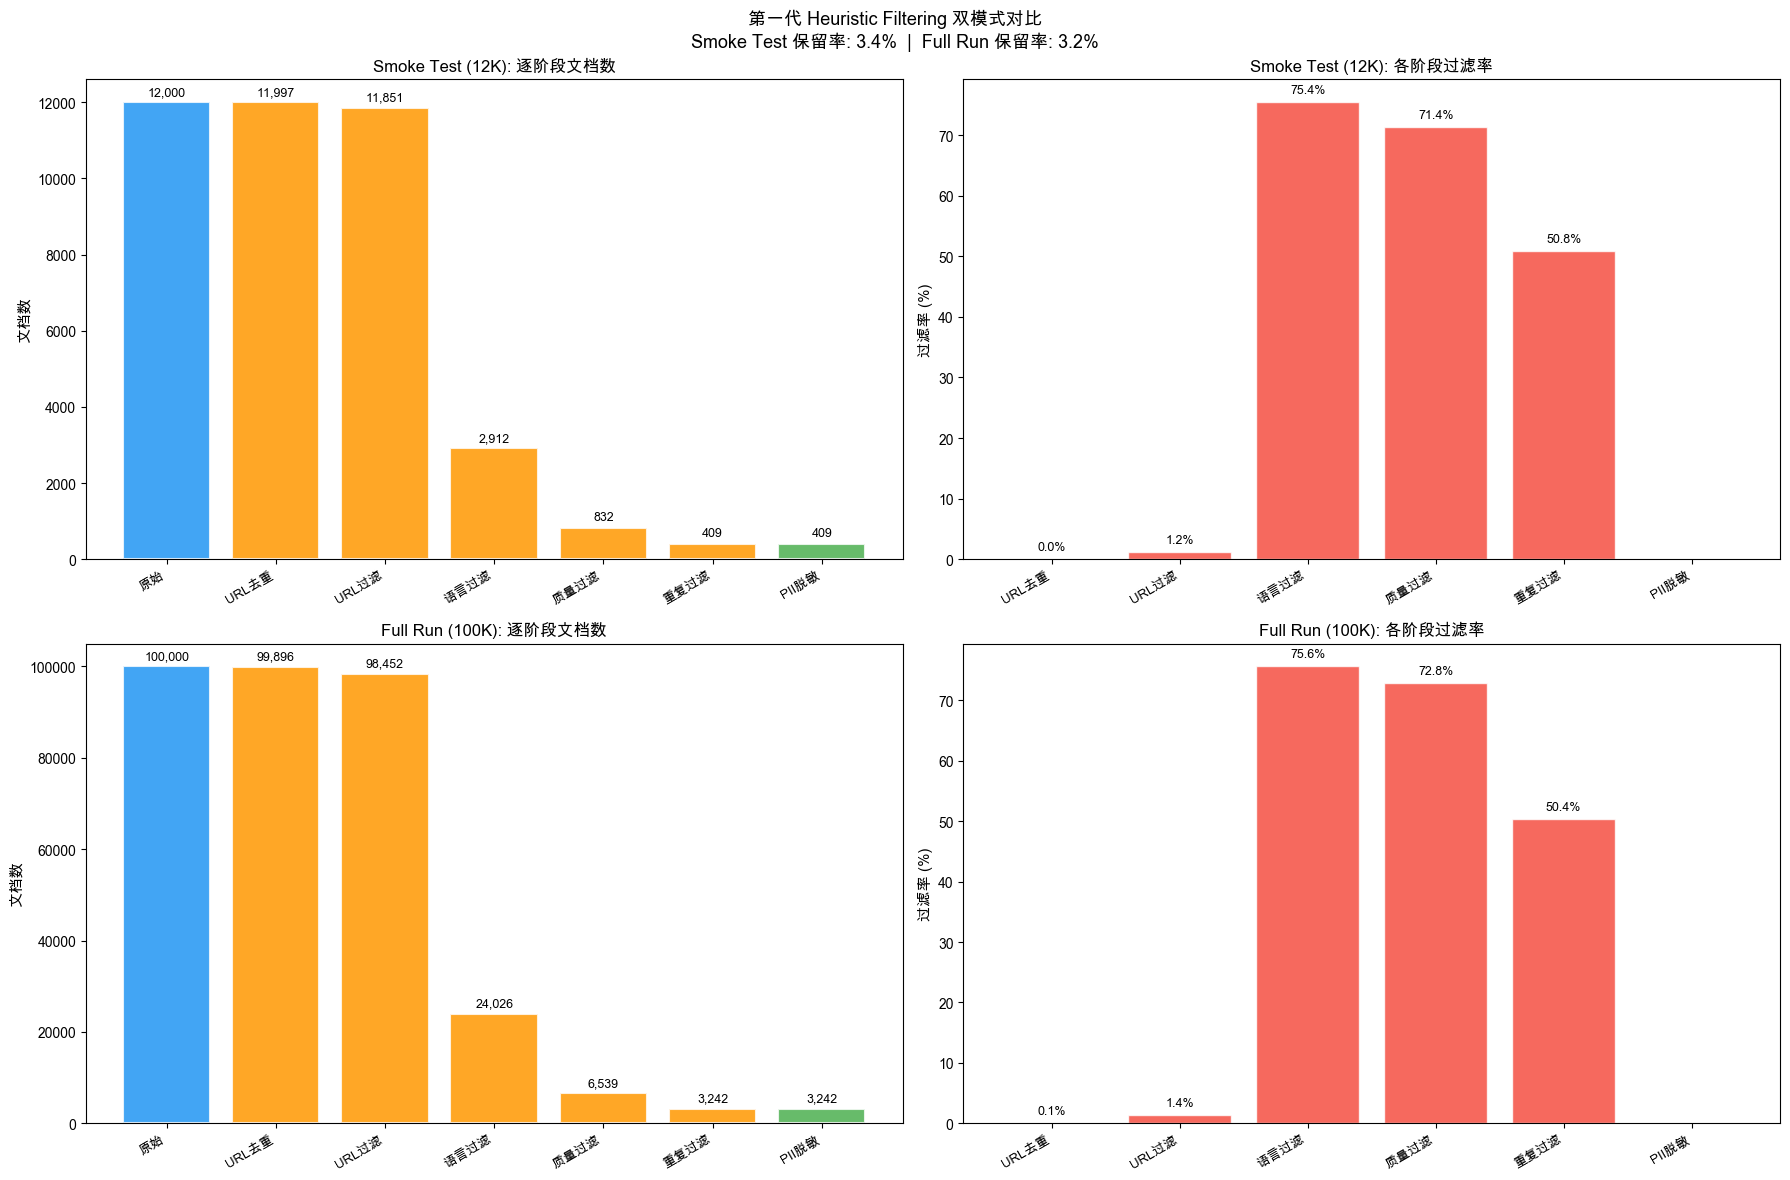

In [10]:
# === Cell 10: 双模式瀑布图（2x2 布局） ===
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

step_names_ordered = {
    'url_dedup': 'URL去重',
    'url_filter': 'URL过滤',
    'language_filter': '语言过滤',
    'quality_filter': '质量过滤',
    'repetition_filter': '重复过滤',
    'pii_filter': 'PII脱敏',
}

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

for row_idx, mode in enumerate(MODES):
    d = dual_data[mode]
    label = MODE_LABELS[mode]

    stages = ['原始']
    counts = [d['input_count']]
    filter_rates = [0.0]

    for s in d['pipeline_stats']:
        stage_label = step_names_ordered.get(s['step'], s['step'])
        stages.append(stage_label)
        counts.append(s['after'])
        filter_rates.append(s['filter_rate'])

    ax1 = axes[row_idx, 0]
    ax2 = axes[row_idx, 1]

    # 文档数瀑布
    colors = ['#2196F3' if i == 0
              else '#4CAF50' if i == len(counts) - 1
              else '#FF9800'
              for i in range(len(counts))]
    bars = ax1.bar(stages, counts, color=colors, alpha=0.85,
                   edgecolor='white', linewidth=1.5)
    ax1.set_ylabel('文档数', fontsize=11)
    ax1.set_title(f'{label}: 逐阶段文档数', fontweight='bold', fontsize=12)
    ax1.set_xticklabels(stages, rotation=30, ha='right', fontsize=9.5)
    for bar, count in zip(bars, counts):
        ax1.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + max(counts) * 0.01,
                 f'{count:,}', ha='center', va='bottom', fontsize=9)

    # 过滤率条形图
    ax2.bar(stages[1:], [r * 100 for r in filter_rates[1:]],
            color='#f44336', alpha=0.8, edgecolor='white')
    ax2.set_ylabel('过滤率 (%)', fontsize=11)
    ax2.set_title(f'{label}: 各阶段过滤率', fontweight='bold', fontsize=12)
    ax2.set_xticklabels(stages[1:], rotation=30, ha='right', fontsize=9.5)
    for j, r in enumerate(filter_rates[1:]):
        if r > 0:
            ax2.text(j, r * 100 + 1, f'{r:.1%}', ha='center', va='bottom', fontsize=9)

plt.suptitle(
    f'第一代 Heuristic Filtering 双模式对比\n'
    f'Smoke Test 保留率: {dual_data["smoke_test"]["retention_rate"]:.1%}  |  '
    f'Full Run 保留率: {dual_data["full_run"]["retention_rate"]:.1%}',
    fontweight='bold', fontsize=13
)
plt.tight_layout()

import os
os.makedirs('../results/figures', exist_ok=True)
plt.savefig('../results/figures/02_gen1_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

## H. 过滤贡献分解（含子过滤器级别）

In [11]:
# === Cell 11: 过滤贡献分解（大类 + 小类） ===
print("=" * 90)
print("  各阶段过滤贡献（含子过滤器级别）")
print("=" * 90)

for mode in MODES:
    d = dual_data[mode]
    label = MODE_LABELS[mode]
    total_filtered = d['input_count'] - d['output_count']

    print(f"\n  [{label}] 总过滤: {total_filtered:,} 条")
    print(f"  {'过滤器':<35} {'过滤数':>8} {'占总过滤':>10} {'占该步输入':>12}")
    print(f"  {'-'*70}")

    for s in d['pipeline_stats']:
        name = step_names.get(s['step'], s['step'])
        if s['filtered'] > 0:
            pct_total = s['filtered'] / total_filtered
            pct_input = s['filter_rate']
            print(f"  {name:<35} {s['filtered']:>8,} {pct_total:>10.1%} {pct_input:>12.1%}")

            # 子过滤器分解（如果有 reason_breakdown）
            rb = s.get('reason_breakdown', {})
            if rb and len(rb) > 1:
                for reason, count in sorted(rb.items(), key=lambda x: -x[1]):
                    pct_sub = count / s['filtered']
                    print(f"    -> {reason:<31} {count:>8,} ({pct_sub:.0%} of this filter)")

    print(f"  {'─'*70}")
    print(f"  {'总计':<35} {total_filtered:>8,}")

print()

  各阶段过滤贡献（含子过滤器级别）

  [Smoke Test (12K)] 总过滤: 11,591 条
  过滤器                                      过滤数       占总过滤        占该步输入
  ----------------------------------------------------------------------
  URL 去重                                     3       0.0%         0.0%
  URL 过滤                                   146       1.3%         1.2%
    -> blacklist_keyword                    135 (92% of this filter)
    -> ip_address_url                         7 (5% of this filter)
    -> blacklist_tld                          4 (3% of this filter)
  语言过滤                                   8,939      77.1%        75.4%
  质量过滤(Gopher+C4+FineWeb)                2,080      17.9%        71.4%
    -> c4                                 1,210 (58% of this filter)
    -> gopher                               870 (42% of this filter)
  重复过滤                                     423       3.6%        50.8%
    -> dup_5gram_fraction                   360 (85% of this filter)
    -> dup_line_fraction          

## I. 第一代汇总结论

In [12]:
# === Cell 12: 最终汇总 ===
print("=" * 80)
print("  第一代 Heuristic Filtering — 最终结论")
print("=" * 80)

for mode in MODES:
    d = dual_data[mode]
    label = MODE_LABELS[mode]

    output_metrics = [m for m in d['stage_metrics'] if m.get('stage') == 'gen1_output']
    est_tokens = output_metrics[0].get('estimated_total_tokens', 0) if output_metrics else 0
    avg_tokens = output_metrics[0].get('avg_tokens_per_doc', 0) if output_metrics else 0

    print(f"\n  [{label}]")
    print(f"  {'─' * 60}")
    print(f"  输入文档数:     {d['input_count']:>10,}")
    print(f"  输出文档数:     {d['output_count']:>10,}")
    print(f"  总保留率:       {d['retention_rate']:>10.1%}")
    if est_tokens > 0:
        print(f"  估算 Token 数:  {est_tokens:>10,}")
        print(f"  平均 Token/文档: {avg_tokens:>10,.1f}")

# 关键发现
print(f"\n{'='*80}")
print("  关键发现")
print(f"{'='*80}")
print("  1. 语言过滤是最大的过滤器（~75%），因为 CC WET 英文占比仅 ~25-35%")
print("  2. 质量过滤（Gopher+C4）过滤 ~70% 的英文文档，主要是短文本和低标点率")
print("  3. 重复过滤再过滤 ~50%，主要触发规则是 5-gram 重复（模板/导航内容）")
print("  4. 两档（12K/100K）保留率一致（~3.2-3.4%），smoke_test 代表性良好")
print("  5. FineWeb 补充规则未触发，说明 Gopher+C4 已覆盖了大部分低质量内容")
print()
print("  下一步 -> Notebook 03：第二代 Model-based Filtering")
print('  预期：fastText 分类器将进一步区分"平庸内容"和"高质量内容"')

  第一代 Heuristic Filtering — 最终结论

  [Smoke Test (12K)]
  ────────────────────────────────────────────────────────────
  输入文档数:         12,000
  输出文档数:            409
  总保留率:             3.4%
  估算 Token 数:     422,611
  平均 Token/文档:    1,033.3

  [Full Run (100K)]
  ────────────────────────────────────────────────────────────
  输入文档数:        100,000
  输出文档数:          3,242
  总保留率:             3.2%
  估算 Token 数:   3,757,931
  平均 Token/文档:    1,159.1

  关键发现
  1. 语言过滤是最大的过滤器（~75%），因为 CC WET 英文占比仅 ~25-35%
  2. 质量过滤（Gopher+C4）过滤 ~70% 的英文文档，主要是短文本和低标点率
  3. 重复过滤再过滤 ~50%，主要触发规则是 5-gram 重复（模板/导航内容）
  4. 两档（12K/100K）保留率一致（~3.2-3.4%），smoke_test 代表性良好
  5. FineWeb 补充规则未触发，说明 Gopher+C4 已覆盖了大部分低质量内容

  下一步 -> Notebook 03：第二代 Model-based Filtering
  预期：fastText 分类器将进一步区分"平庸内容"和"高质量内容"


In [13]:
# === Cell 13: 保存五维 Profile ===
import os
os.makedirs('../results', exist_ok=True)

profiles = {
    'gen1_input': input_profile,
    'gen1_output': output_profile,
}

profile_path = '../results/gen1_5dim_profile.json'
with open(profile_path, 'w', encoding='utf-8') as f:
    json.dump(profiles, f, ensure_ascii=False, indent=2, default=str)
print(f"五维 Profile 已保存: {profile_path}")

五维 Profile 已保存: ../results/gen1_5dim_profile.json
